# Intelligent Rivers · Streamflow
## SUMMA and an LSTM on the Vamanapuram River

**Can a learned model beat a model of water and energy? What does either add beyond the seasonal cycle?**

We study **Vamanapuram at Ayilam, Kerala**, CAMELS-IND gauge **15007**. Its catchment is about **556 km²**. The dataset reports zero dams in both dam inventories. That is a useful screening result, not proof of natural flow.

This follows the [Logan workshop](04a_logan_river_workshop.ipynb): settings, basin, inputs, a baseline run, fitting, and testing. We add a small LSTM and compare all predictors on the same dates.

CAMELS-IND covers peninsular India. This is a monsoon river, not a Himalayan snow basin. The [bundled subset](data/camels_ind_15007/README.txt) contains real observed discharge, the basin boundary, and source metadata. It excludes CAMELS' supplied LSTM predictions.

```bash
symfluence example launch 04e
```

| Time | Activity |
|---|---|
| 10 min | Inspect the basin and flow |
| 10 min | Inspect shared weather |
| 10 min | Run and fit SUMMA |
| 10 min | Train the LSTM |
| 15 min | Compare the holdout |

**Before class:** prepare ERA5, attributes, SUMMA calibration and the LSTM. Downloads and fitting are outside this 55-minute plan. Neither model's score is known in advance.

## 1 · Open the experiment

Use the repository environment, including its `ml` extra for PyTorch and scikit-learn. SUMMA and CDS credentials are needed for a fresh run. Keep credentials outside the notebook.

`RUN_STEPS = True` runs preparation, SUMMA and its calibration, then native LSTM training. Use a fresh kernel. Do not run the same project from the CLI at the same time.

Set it to `False` to inspect prepared model outputs. The bundled observations and boundary remain available. Later analyses stop with an error if required model inputs or outputs are absent.

The [YAML](config_ayilam_streamflow.yaml) holds dates and model settings. `SYMFLUENCE_DATA_DIR` can override its data directory, including on JupyterHub. The notebook finds the checkout from any directory inside it.

In [1]:
import os
import sys
import json
import hashlib
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import symfluence as sf_package
from IPython.display import display
from symfluence import SYMFLUENCE
from symfluence.core.config.models import SymfluenceConfig
from symfluence.core.mixins.project import resolve_data_subdir
from symfluence.core.modeling.evaluators.streamflow import StreamflowEvaluator

RUN_STEPS = True
relative_config = Path("examples/04_workshop_notebooks/config_ayilam_streamflow.yaml")
anchors = [Path.cwd(), Path(sf_package.__file__).resolve().parent]
roots = [root for anchor in anchors for root in [anchor, *anchor.parents]]
REPO = next((root for root in roots if (root / relative_config).is_file()), None)
if REPO is None:
    raise FileNotFoundError("Open 04e inside a SYMFLUENCE checkout.")
os.chdir(REPO)
workshop = REPO / relative_config.parent
sys.path.insert(0, str(workshop))
from intelligent_rivers_streamflow import (
    load_bundle, daily_summa_forcing, write_daily_forcing, comparison_scores,
)

CONFIG_PATH = REPO / relative_config
config = SymfluenceConfig.from_file(CONFIG_PATH)
project = config.system.data_dir / f"domain_{config.domain.name}"
experiment = config.domain.experiment_id
start, end = pd.Timestamp(config.domain.time_start), pd.Timestamp(config.domain.time_end)
days = pd.date_range(start.normalize(), end.normalize(), freq="D")
cal_start, cal_end = [pd.Timestamp(s.strip()) for s in config.domain.calibration_period.split(",")]
test_start, test_end = [pd.Timestamp(s.strip()) for s in config.domain.evaluation_period.split(",")]
logger = logging.getLogger("workshop.streamflow")
BLUE, TEAL, ORANGE, GREY = "#285a7c", "#168a83", "#d97941", "#9aa6af"
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.18, "font.size": 10.5})
print(f"Python: {sys.executable}; SYMFLUENCE: {sf_package.__version__}")
print(f"Config SHA-256: {hashlib.sha256(CONFIG_PATH.read_bytes()).hexdigest()}")
print(f"Project: {project}")
print("Mode:", "run workflow and train" if RUN_STEPS else "inspect prepared outputs")

Python: /Users/darri/repos/SYMFLUENCE/venv/bin/python; SYMFLUENCE: 0.9.2
Config SHA-256: eabe2d36a4f1d8374790aef62a478f5997ffac9f7f8563e138959fbe78526956
Project: /Users/darri/repos/SYMFLUENCE_data/domain_ayilam_camels_ind
Mode: run workflow and train


### Fix the split before fitting

- **2000:** SUMMA spin-up and LSTM weather history. No scored targets.
- **2001–2010:** SUMMA parameter fitting. The native LSTM uses the first 80% of these target dates for gradient training and scaling, and the last 20% for validation and early stopping.
- **2011–2015:** one shared holdout. Neither optimizer sees these flow targets during fitting.

The observations are complete over these dates. We check this before training. If you change the basin or dates, repair missing-target handling before using the native LSTM. Do not compress time or fill target gaps with model predictions.

This is a test at one gauged site. It does not establish skill at other rivers.

In [2]:
basin, observed, source = load_bundle(workshop / "data" / "camels_ind_15007")
observed = observed.reindex(days)
if observed.isna().any():
    raise ValueError("The bundled flow does not cover these experiment dates.")
display(pd.DataFrame([
    ("River / gauge", "Vamanapuram / Ayilam (15007)"),
    ("GHI catchment area", source["attributes"]["topo"]["ghi_area"]),
    ("Mean / maximum elevation (m)",
     f'{source["attributes"]["topo"]["elev_mean"]:.0f} / {source["attributes"]["topo"]["elev_max"]}'),
    ("Dam inventories", f'{source["attributes"]["anth"]["num_dams"]} / {source["attributes"]["anth"]["n_dams"]}'),
    ("Spin-up", config.domain.spinup_period),
    ("Fit / validation", config.domain.calibration_period),
    ("Holdout", config.domain.evaluation_period),
    ("SUMMA budget", f"{config.optimization.iterations} DDS iterations"),
    ("LSTM budget", f"up to {config.model.lstm.epochs} epochs; {config.model.lstm.lookback}-day history"),
], columns=["Setting", "Value"]).set_index("Setting"))
coverage = observed.groupby(observed.index.year).agg(["count", "mean", "max"])
coverage["zero_flow_days"] = observed.eq(0).groupby(observed.index.year).sum()
display(coverage)

,Value
Setting,
River / gauge,Vamanapuram / Ayilam (15007)
GHI catchment area,555.8
Mean / maximum elevation (m),193 / 1592
Dam inventories,0 / 0
Spin-up,"2000-01-01,2000-12-31"
Fit / validation,"2001-01-01,2010-12-31"
Holdout,"2011-01-01,2015-12-31"
SUMMA budget,50 DDS iterations
LSTM budget,up to 30 epochs; 90-day history


,count,mean,max,zero_flow_days
2000,366,17.767459,341.41,13
2001,365,20.417178,360.15,72
2002,365,13.708548,203.96,148
2003,365,9.657370,207.67,196
2004,366,24.705137,201.23,112
2005,365,28.044685,296.22,80
2006,365,28.326055,287.23,113
2007,365,27.296356,323.28,132
2008,366,16.033634,223.12,191
2009,365,13.526493,331.40,163


## 2 · Import the basin and observations

Use the CAMELS boundary instead of delineating a new watershed from the gauge. That keeps spatial support tied to the observed record. We write the standard basin fields and observation CSV used by SYMFLUENCE. No CAMELS-IND online handler is needed.

We use GHI's corrected gauge coordinates. The polygon area computed in UTM may differ slightly from the rounded attribute area. SUMMA uses the polygon-derived HRU area. One HRU represents the whole catchment; it does not resolve hillslope or land-cover differences.

09:16:20 ● ============================================================
SYMFLUENCE Logging Initialized
Domain: ayilam_camels_ind
Experiment ID: intelligent_rivers_streamflow_summa
Log Level: INFO
Log File: /Users/darri/repos/SYMFLUENCE_data/domain_ayilam_camels_ind/_workLog_ayilam_camels_ind/symfluence_ayilam_camels_ind_intelligent_rivers_streamflow_summa_20261006_091620.log
09:16:20 ● Configuration logged to: /Users/darri/repos/SYMFLUENCE_data/domain_ayilam_camels_ind/_workLog_ayilam_camels_ind/config_ayilam_camels_ind_20261006_091620.yaml
09:16:20 ● SYMFLUENCE initialized
09:16:20 ● Config path: /Users/darri/repos/SYMFLUENCE/examples/04_workshop_notebooks/config_ayilam_streamflow.yaml
09:16:22 ● Starting individual step execution: setup_project, create_pour_point
09:16:22 ● 
┌──────────────────────────────────────────────────────────┐
│ Step 1/2: setup_project                                  │
│ Setting up project structure and directories             │
└────────────────────────────

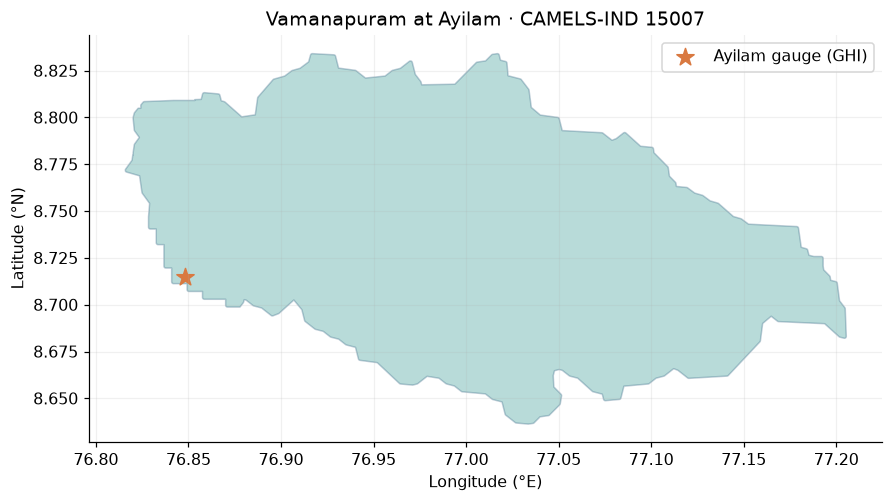

In [3]:
workflow = None

def run_stage(names):
    global workflow
    if not RUN_STEPS:
        print("Inspect mode — skipped:", ", ".join(names))
        return
    if workflow is None:
        workflow = SYMFLUENCE(config, visualize=False)
    workflow.run_individual_steps(names)

basin_file = project / "shapefiles" / "river_basins" / f"{config.domain.name}_riverBasins_lumped.shp"
obs_file = (resolve_data_subdir(project, "observations") / "streamflow" / "preprocessed"
            / f"{config.domain.name}_streamflow_processed.csv")
area_m2 = float(basin.to_crs(basin.estimate_utm_crs()).area.sum())
if RUN_STEPS:
    run_stage(["setup_project", "create_pour_point"])
    basin_file.parent.mkdir(parents=True, exist_ok=True)
    native_basin = basin.copy()
    native_basin["GRU_ID"] = 1
    native_basin["gru_to_seg"] = 1
    native_basin["GRU_area"] = area_m2
    native_basin.to_file(basin_file)
    obs_file.parent.mkdir(parents=True, exist_ok=True)
    observed.rename("discharge_cms").rename_axis("datetime").to_csv(obs_file)
    log_dir = project / "workshop" / experiment
    log_dir.mkdir(parents=True, exist_ok=True)
    (log_dir / "camels_provenance.json").write_text(json.dumps(source, indent=2))
    (log_dir / "config_resolved.json").write_text(json.dumps(config.to_dict(flatten=True), default=str, indent=2))
print(f"Imported footprint: {area_m2 / 1e6:.2f} km²; GHI attribute: {source['attributes']['topo']['ghi_area']} km²")

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
basin.plot(ax=ax, facecolor=TEAL, edgecolor=BLUE, alpha=0.3)
lat, lon = map(float, config.domain.pour_point_coords.split("/"))
ax.scatter(lon, lat, marker="*", s=140, color=ORANGE, label="Ayilam gauge (GHI)")
ax.set(xlabel="Longitude (°E)", ylabel="Latitude (°N)", title="Vamanapuram at Ayilam · CAMELS-IND 15007")
ax.legend()
plt.show()

## 3 · Prepare shared weather

SYMFLUENCE acquires elevation, soil and land cover, builds one HRU, fetches hourly ERA5, and prepares SUMMA inputs. ERA5 is reanalysis. It can have biases in monsoon rain and mountain weather.

The LSTM receives daily means of the **seven weather variables in SUMMA's forcing manifest**. Precipitation remains a mean rate; multiplying by 86,400 gives mm/day. There are no observed-flow lags, SUMMA states, CAMELS soil-moisture predictors, or CAMELS modelled-flow inputs.

We require complete days and a continuous daily weather axis. The helper rejects gaps, mixed units, extra HRUs and conflicting timestamps.

In [ ]:
run_stage(["acquire_attributes", "discretize_domain", "acquire_forcings",
           "model_agnostic_preprocessing", "model_specific_preprocessing"])
hru_file = (project / "shapefiles" / "catchment" / "lumped" / experiment
            / f"{config.domain.name}_HRUs_GRUs.shp")
hrus = gpd.read_file(hru_file)
if len(hrus) != 1:
    raise ValueError("04e expects a single lumped HRU.")
display(hrus[[name for name in ["HRU_ID", "HRU_area", "elev_mean"] if name in hrus]])
daily_weather, forcing_hashes = daily_summa_forcing(project, config)
print(f"Shared weather: {len(daily_weather)} complete days from {len(forcing_hashes)} SUMMA input files.")
display(daily_weather.describe().round(3))

09:16:22 ● Starting individual step execution: acquire_attributes, discretize_domain, acquire_forcings, model_agnostic_preprocessing, model_specific_preprocessing
09:16:22 ● 
┌──────────────────────────────────────────────────────────┐
│ Step 1/5: acquire_attributes                             │
│ Acquiring geospatial attributes and data                 │
└──────────────────────────────────────────────────────────┘
09:16:22 ● Starting attribute acquisition
09:16:22 ● Cloud data access enabled for attributes (DEM_SOURCE: copdem90)
09:16:22 ● Acquiring attributes: 3 tasks (serial)
09:16:22 ● Downloading Copernicus DEM GLO-90 for bbox: {'lat_min': 8.57, 'lat_max': 8.9, 'lon_min': 76.75, 'lon_max': 77.27}
09:16:22 ● Fetching tile: Copernicus_DSM_COG_30_N08_00_E076_00_DEM
09:16:23 ● Downloaded Copernicus_DSM_COG_30_N08_00_E076_00_DEM
09:16:23 ● Fetching tile: Copernicus_DSM_COG_30_N08_00_E077_00_DEM
09:16:23 ● Downloaded Copernicus_DSM_COG_30_N08_00_E077_00_DEM
09:16:23 ● Merging 2 tiles in

2026-10-06 09:16:26,113 INFO Request ID is 7768a2eb-73ec-4139-a4c1-9c8801f8e87d
2026-10-06 09:16:26,221 INFO status has been updated to accepted
2026-10-06 09:17:02,016 INFO status has been updated to running
2026-10-06 09:20:50,305 INFO status has been updated to successful
2026-10-06 09:20:52,295 INFO Request ID is 4bb5ccdd-c21a-49c0-af5d-dc19bbe71baf                                                                                                       
2026-10-06 09:20:52,395 INFO status has been updated to accepted
2026-10-06 09:21:16,011 INFO status has been updated to running


In [ ]:
def mark_split(ax):
    ax.axvspan(start, cal_start, color=GREY, alpha=0.14, label="Spin-up")
    ax.axvline(test_start, color=GREY, ls="--", lw=1)
    ax.set_xlim(start, end)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, layout="constrained")
axes[0].plot(daily_weather.index, daily_weather.airtemp - 273.15, color=ORANGE)
axes[0].set(ylabel="Temperature (°C)", title="Shared model-input weather and observed discharge")
axes[1].bar(daily_weather.index, daily_weather.pptrate * 86400, width=1, color=BLUE)
axes[1].set_ylabel("Precipitation (mm/day)")
axes[2].plot(observed.index, observed, color=TEAL)
axes[2].set_ylabel("Observed flow (m³/s)")
for ax in axes:
    mark_split(ax)
plt.show()

Daily weather uses UTC dates. CAMELS gives daily flow labels but not enough information here to reconstruct the exact gauge reporting window. We pair the labels without shifting them to improve the score. This is a retrospective simulation with known weather, not a weather forecast.

## 4 · Run a SUMMA baseline

SUMMA models water and energy in a land column. Its native sub-grid time-delay routing represents a lumped flow response; we do not build a channel network. The evaluator converts runoff to m³/s using the HRU area.

Read hourly runoff from every timestep output file. Score complete daily means after spin-up.

In [ ]:
run_stage(["run_model", "postprocess_results"])
evaluator = StreamflowEvaluator(config, project_dir=project, logger=logger)

def read_summa(folder):
    files = sorted(folder.glob("*_timestep.nc"))
    if not files:
        raise FileNotFoundError(f"No SUMMA timestep output in {folder}")
    flow = pd.concat([evaluator.extract_simulated_data([path]) for path in files]).sort_index()
    flow.index = pd.DatetimeIndex(flow.index).round("h")
    if flow.index.has_duplicates:
        if (flow.groupby(level=0).nunique(dropna=False) > 1).any():
            raise ValueError("Conflicting SUMMA flow at duplicate timestamps.")
        flow = flow.loc[~flow.index.duplicated()]
    daily = flow.resample("D").mean()
    daily = daily.where(flow.resample("D").count() == 86400 // config.forcing.time_step_size)
    return daily.reindex(days)

baseline = read_summa(project / "simulations" / experiment / "SUMMA")
baseline_frame = pd.DataFrame({"Observed": observed, "SUMMA baseline": baseline})
baseline_scores, _ = comparison_scores(baseline_frame, config.domain.calibration_period)
display(baseline_scores.round(3))

## 5 · Fit SUMMA on 2001–2010

Native DDS fits soil conductivity, aquifer baseflow rate, and two sub-grid routing parameters. Bounds come from SUMMA's parameter files. The objective is daily KGE. Higher is better; one is a perfect score.

Fifty iterations is a teaching budget, not a convergence claim. Keep the holdout dates and settings fixed. A fitted parameter can compensate for an input bias. A better fit does not prove the process is right.

In [ ]:
run_stage(["calibrate_model"])
optimization_dir = (project / "optimization" / "SUMMA"
                    / f"{config.optimization.algorithm.lower()}_{experiment}")
calibrated = read_summa(optimization_dir / "final_evaluation")
best_file = optimization_dir / f"{experiment}_dds_best_params.json"
if not best_file.exists():
    raise FileNotFoundError(f"Missing native calibration result: {best_file}")
best = json.loads(best_file.read_text())
display(pd.Series(best["best_params"], name="fitted_value").to_frame())
history_file = optimization_dir / f"{experiment}_parallel_iteration_results.csv"
history = pd.read_csv(history_file)
starts = history.index[history.iteration == 0]
if len(starts):
    history = history.loc[starts[-1]:]
fig, ax = plt.subplots(layout="constrained")
ax.plot(history.iteration, history.score.cummax(), color=BLUE)
ax.set(xlabel="DDS iteration", ylabel="Best KGE", title="SUMMA fitting · 2001–2010 only")
plt.show()

## 6 · Train the native LSTM

The LSTM receives the previous **90 days** of daily weather and predicts daily discharge. The native sequence builder excludes the target day's weather. SUMMA uses current hourly weather as well as its evolving stores. Both draw from the same source, but their temporal inputs and model structures differ.

We use SYMFLUENCE's `LSTMRunner`, `LSTMPreProcessor` and `LSTMModel`. We point the preprocessor at a separate daily file; hourly SUMMA inputs remain intact. No separate trainer is introduced.

The native runner fits scalers and gradients on the first 80% of targets inside 2001–2010. Validation, learning-rate changes and early stopping use the remaining 20%. We print the exact boundary. Holdout flow never enters scaling, gradient training or model selection.

The network has one layer with 32 hidden units. It trains for at most 30 epochs with native Smooth L1 loss and AdamW. This loss differs from SUMMA's KGE objective; the comparison tests these two small workshop setups, not an intrinsic ranking of physics and machine learning. A fixed seed helps repeat the run, but devices can still change results.

In [ ]:
from symfluence.models.lstm.runner import LSTMRunner

lstm_experiment = experiment.removesuffix("_summa") + "_lstm"
lstm_config = SymfluenceConfig.from_file(CONFIG_PATH, overrides={
    "HYDROLOGICAL_MODEL": "LSTM", "EXPERIMENT_ID": lstm_experiment,
})
lstm_dir = project / "simulations" / lstm_experiment / "LSTM"
daily_file = (resolve_data_subdir(project, "forcing") / "LSTM_daily" / lstm_experiment
              / f"{config.domain.name}_ERA5_remapped_grus_daily.nc")
fit_dates = days[config.model.lstm.lookback:]
fit_dates = fit_dates[(fit_dates >= cal_start) & (fit_dates <= cal_end)]
split = int(0.8 * len(fit_dates))
print(f"Gradient/scaler targets: {fit_dates[0].date()} to {fit_dates[split-1].date()}")
print(f"Validation targets: {fit_dates[split].date()} to {fit_dates[-1].date()}")
print(f"Holdout: {test_start.date()} to {test_end.date()}")

if RUN_STEPS:
    write_daily_forcing(daily_weather, daily_file)
    runner = LSTMRunner(lstm_config, logger)
    runner.preprocessor.forcing_basin_path = daily_file.parent
    print(f"LSTM device: {runner.device}")
    runner.run_lstm()
    run_metadata = {
        "config": lstm_config.to_dict(flatten=True),
        "forcing_sha256": forcing_hashes,
        "daily_forcing_sha256": hashlib.sha256(daily_file.read_bytes()).hexdigest(),
        "device": str(runner.device), "symfluence_version": sf_package.__version__,
        "scaler_training_end": str(fit_dates[split-1]),
        "validation_start": str(fit_dates[split]),
    }
    (lstm_dir / "workshop_provenance.json").write_text(json.dumps(run_metadata, default=str, indent=2))

lstm_file = lstm_dir / f"{lstm_experiment}_LSTM_output.nc"
if not lstm_file.exists():
    raise FileNotFoundError(f"Train the LSTM or prepare its output: {lstm_file}")
with xr.open_dataset(lstm_file) as ds:
    if ds.predicted_streamflow.attrs.get("units") != "m3 s-1":
        raise ValueError("Check LSTM flow units before scoring.")
    lstm = ds.predicted_streamflow.load().to_series().reindex(days)
print("Raw negative LSTM predictions:", int((lstm < 0).sum()))

## 7 · Compare both with climatology

Fit mean-flow and monthly-climatology predictors using only **2001–2010**. Apply them unchanged to 2011–2015. We keep raw model predictions, including negative LSTM values, and report negative-day counts. No silent clipping improves the scores.

NSE and KGE have a best value of one. Positive PBIAS means overprediction. MAE is in m³/s. KGE is undefined for a constant predictor; use NSE and MAE for mean flow.

Every row in a period uses the same finite dates across observations and all predictors. Report paired days with scores. The fitting-period LSTM score includes both gradient-training and validation targets; it is not a holdout score.

In [ ]:
fit_flow = observed.loc[cal_start:cal_end]
monthly_mean = fit_flow.groupby(fit_flow.index.month).mean()
monthly = pd.Series(days.month.map(monthly_mean), index=days)
comparison = pd.DataFrame({
    "Observed": observed, "Mean flow": fit_flow.mean(), "Monthly climatology": monthly,
    "SUMMA baseline": baseline, "SUMMA calibrated": calibrated, "LSTM": lstm,
})
tables = {}
paired = {}
for name, period in [("Fit / validation", config.domain.calibration_period),
                     ("Holdout", config.domain.evaluation_period)]:
    tables[name], paired[name] = comparison_scores(comparison, period)
display(pd.concat(tables, names=["period", "predictor"]).round(3))

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
tables["Holdout"]["NSE"].plot.barh(ax=ax, color=[GREY, GREY, BLUE, TEAL, ORANGE])
ax.axvline(0, color=GREY, lw=1)
ax.set(xlabel="Holdout NSE", title="Does either model beat training-period climatology?")
plt.show()

In [ ]:
view = paired["Holdout"]
colors = {"Observed": "#202a35", "Monthly climatology": GREY,
          "SUMMA baseline": BLUE, "SUMMA calibrated": TEAL, "LSTM": ORANGE}
fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")
for name, color in colors.items():
    series = view[name]
    axes[0, 0].plot(series.index, series, color=color, lw=0.8, label=name)
    seasonal = series.groupby(series.index.month).mean()
    axes[1, 0].plot(seasonal.index, seasonal, color=color, marker="o", ms=3)
    sorted_flow = series.sort_values(ascending=False).to_numpy()
    exceedance = np.arange(1, len(sorted_flow) + 1) / (len(sorted_flow) + 1) * 100
    axes[1, 1].plot(exceedance, sorted_flow, color=color)
for name in ["SUMMA calibrated", "LSTM"]:
    axes[0, 1].scatter(view.Observed, view[name], s=8, alpha=0.25, color=colors[name], label=name)
limits = [min(0, view[["Observed", "SUMMA calibrated", "LSTM"]].min().min()),
          view[["Observed", "SUMMA calibrated", "LSTM"]].max().max()]
axes[0, 1].plot(limits, limits, color=GREY, ls="--")
axes[0, 0].set(ylabel="Discharge (m³/s)", title="Held-out daily flow · 2011–2015")
axes[0, 0].legend(fontsize=8, ncol=2)
axes[0, 1].set(xlabel="Observed (m³/s)", ylabel="Predicted (m³/s)", title="Peaks and bias")
axes[0, 1].legend()
axes[1, 0].set(xlabel="Month", ylabel="Mean flow (m³/s)", title="Seasonal flow on common dates", xticks=range(1, 13))
axes[1, 1].set(xlabel="Exceedance probability (%)", ylabel="Discharge (m³/s)", title="Flow-duration curve · zeros and negatives retained")
axes[1, 1].set_yscale("symlog", linthresh=1)
plt.show()

annual = []
for year in range(test_start.year, test_end.year + 1):
    scores, _ = comparison_scores(comparison, f"{year}-01-01,{year}-12-31")
    scores["year"] = year
    annual.append(scores.reset_index())
display(pd.concat(annual).set_index(["year", "predictor"])[["NSE", "KGE", "PBIAS (%)", "paired_days"]].round(3))